In [1]:
import numpy as np
import pandas as pd

from google.colab import drive
drive.mount("/content/drive")

canonical_df = pd.read_pickle(
    "/content/drive/MyDrive/router_project_canonical.pkl"
)

splits = np.load(
    "/content/drive/MyDrive/router_split_indices.npz"
)

train_idx = splits["train_idx"]
val_idx = splits["val_idx"]
test_idx = splits["test_idx"]

print("Dataset shape:", canonical_df.shape)
print("Train:", len(train_idx))
print("Validation:", len(val_idx))
print("Test:", len(test_idx))

Mounted at /content/drive
Dataset shape: (22962, 26)
Train: 18369
Validation: 2296
Test: 2297


In [4]:
MODEL_COLS = [
    "WizardLM/WizardLM-13B-V1.2",
    "claude-instant-v1",
    "claude-v1",
    "claude-v2",
    "gpt-3.5-turbo-1106",
    "gpt-4-1106-preview",
    "meta/code-llama-instruct-34b-chat",
    "meta/llama-2-70b-chat",
    "mistralai/mistral-7b-chat",
    "mistralai/mixtral-8x7b-chat",
    "zero-one-ai/Yi-34B-Chat"
]

In [5]:
X = canonical_df[
    ["sample_id", "prompt", "domain", "eval_name"]
].copy()

Y = pd.DataFrame({
    model: canonical_df[f"{model}|performance"]
    for model in MODEL_COLS
})

C = pd.DataFrame({
    model: canonical_df[f"{model}|cost"]
    for model in MODEL_COLS
})

In [6]:
X_train = X.iloc[train_idx].reset_index(drop=True)
X_val   = X.iloc[val_idx].reset_index(drop=True)
X_test  = X.iloc[test_idx].reset_index(drop=True)

Y_train = Y.iloc[train_idx].reset_index(drop=True)
Y_val   = Y.iloc[val_idx].reset_index(drop=True)
Y_test  = Y.iloc[test_idx].reset_index(drop=True)

C_train = C.iloc[train_idx].reset_index(drop=True)
C_val   = C.iloc[val_idx].reset_index(drop=True)
C_test  = C.iloc[test_idx].reset_index(drop=True)

print(X_train.shape, Y_train.shape, C_train.shape)
print(X_val.shape, Y_val.shape, C_val.shape)
print(X_test.shape, Y_test.shape, C_test.shape)

(18369, 4) (18369, 11) (18369, 11)
(2296, 4) (2296, 11) (2296, 11)
(2297, 4) (2297, 11) (2297, 11)


In [9]:
from sklearn.feature_extraction.text import TfidfVectorizer

vectorizer = TfidfVectorizer(
    max_features=30000,
    ngram_range=(1, 2),
    min_df=2,
    max_df=0.95,
    sublinear_tf=True
)

X_train_tfidf = vectorizer.fit_transform(
    X_train["prompt"]
)

X_val_tfidf = vectorizer.transform(
    X_val["prompt"]
)

X_test_tfidf = vectorizer.transform(
    X_test["prompt"]
)

print("Train TF-IDF shape:", X_train_tfidf.shape)
print("Validation TF-IDF shape:", X_val_tfidf.shape)
print("Test TF-IDF shape:", X_test_tfidf.shape)

Train TF-IDF shape: (18369, 30000)
Validation TF-IDF shape: (2296, 30000)
Test TF-IDF shape: (2297, 30000)


In [13]:
from sklearn.linear_model import Ridge

ridge = Ridge(
    alpha=1.0
)

ridge.fit(
    X_train_tfidf,
    Y_train
)

print("Ridge baseline trained.")

Ridge baseline trained.


In [14]:
val_pred = ridge.predict(
    X_val_tfidf
)

print("Prediction shape:", val_pred.shape)

print(
    "Prediction range before clipping:",
    val_pred.min(),
    "to",
    val_pred.max()
)

Prediction shape: (2296, 11)
Prediction range before clipping: -0.2910045761969254 to 1.3227366548912207


In [15]:
val_pred = np.clip(
    val_pred,
    0.0,
    1.0
)

print(
    "Prediction range after clipping:",
    val_pred.min(),
    "to",
    val_pred.max()
)

Prediction range after clipping: 0.0 to 1.0


In [16]:
from sklearn.metrics import mean_squared_error, mean_absolute_error

mse = mean_squared_error(
    Y_val,
    val_pred
)

mae = mean_absolute_error(
    Y_val,
    val_pred
)

print("Validation MSE:", mse)
print("Validation MAE:", mae)

Validation MSE: 0.13233901628037106
Validation MAE: 0.278425020652852


In [17]:
mean_train_cost = C_train.mean().to_numpy()

for model, cost in zip(
    MODEL_COLS,
    mean_train_cost
):
    print(model, "->", cost)

WizardLM/WizardLM-13B-V1.2 -> 7.9269856e-05
claude-instant-v1 -> 0.00026399308
claude-v1 -> 0.0023590098
claude-v2 -> 0.0027059794
gpt-3.5-turbo-1106 -> 0.00026386313
gpt-4-1106-preview -> 0.003713676
meta/code-llama-instruct-34b-chat -> 0.00018116446
meta/llama-2-70b-chat -> 0.00021006948
mistralai/mistral-7b-chat -> 4.8790404e-05
mistralai/mixtral-8x7b-chat -> 0.00014154297
zero-one-ai/Yi-34B-Chat -> 0.00019933419


In [18]:
def route_predictions(
    predictions,
    model_costs,
    threshold
):
    choices = []

    cost_order = np.argsort(model_costs)

    for scores in predictions:

        eligible = [
            k
            for k in cost_order
            if scores[k] >= threshold
        ]

        if len(eligible) > 0:
            selected = eligible[0]
        else:
            selected = int(
                np.argmax(scores)
            )

        choices.append(selected)

    return np.array(choices)

In [19]:
theta = 0.75

In [20]:
val_choices = route_predictions(
    val_pred,
    mean_train_cost,
    theta
)

rows = np.arange(
    len(val_choices)
)

realised_performance = (
    Y_val.to_numpy()[
        rows,
        val_choices
    ]
)

realised_cost = (
    C_val.to_numpy()[
        rows,
        val_choices
    ]
)

print("Threshold:", theta)

print(
    "Router mean performance:",
    realised_performance.mean()
)

print(
    "Router mean cost:",
    realised_cost.mean()
)

Threshold: 0.75
Router mean performance: 0.6980618
Router mean cost: 0.0018812106


In [21]:
thresholds = np.arange(
    0.10,
    0.96,
    0.05
)

results = []

Y_val_np = Y_val.to_numpy()
C_val_np = C_val.to_numpy()

for theta in thresholds:

    choices = route_predictions(
        val_pred,
        mean_train_cost,
        theta
    )

    rows = np.arange(len(choices))

    realised_performance = Y_val_np[
        rows,
        choices
    ]

    realised_cost = C_val_np[
        rows,
        choices
    ]

    results.append({
        "threshold": theta,
        "mean_performance": realised_performance.mean(),
        "mean_cost": realised_cost.mean()
    })

threshold_results = pd.DataFrame(results)

display(threshold_results)

,threshold,mean_performance,mean_cost
0,0.10,0.356707,0.000050
1,0.15,0.368249,0.000051
2,0.20,0.375109,0.000053
3,0.25,0.397213,0.000057
4,0.30,0.422583,0.000062
5,0.35,0.459386,0.000078
6,0.40,0.489765,0.000098
7,0.45,0.523193,0.000142
8,0.50,0.557927,0.000221
9,0.55,0.592117,0.000377


In [22]:
val_fixed_summary = pd.DataFrame({
    "mean_performance": Y_val.mean(),
    "mean_cost": C_val.mean()
})

val_fixed_summary = val_fixed_summary.sort_values(
    "mean_performance",
    ascending=False
)

display(val_fixed_summary)

,mean_performance,mean_cost
gpt-4-1106-preview,0.775044,0.003638
claude-v1,0.673345,0.002336
claude-v2,0.670949,0.002674
zero-one-ai/Yi-34B-Chat,0.652330,0.000195
gpt-3.5-turbo-1106,0.645470,0.000258
claude-instant-v1,0.622278,0.000259
mistralai/mixtral-8x7b-chat,0.619120,0.000139
WizardLM/WizardLM-13B-V1.2,0.477352,0.000078
mistralai/mistral-7b-chat,0.315875,0.000048
meta/llama-2-70b-chat,0.231163,0.000207


In [23]:
best_fixed_val_model = (
    val_fixed_summary["mean_performance"].idxmax()
)

best_fixed_val_performance = (
    val_fixed_summary.loc[
        best_fixed_val_model,
        "mean_performance"
    ]
)

best_fixed_val_cost = (
    val_fixed_summary.loc[
        best_fixed_val_model,
        "mean_cost"
    ]
)

print("Best fixed validation model:")
print(best_fixed_val_model)

print("\nPerformance:")
print(best_fixed_val_performance)

print("\nCost:")
print(best_fixed_val_cost)

Best fixed validation model:
gpt-4-1106-preview

Performance:
0.77504355

Cost:
0.003637931


In [24]:
EPSILON = 0.01

target_performance = (
    best_fixed_val_performance
    - EPSILON
)

print(
    "Required minimum validation performance:",
    target_performance
)

Required minimum validation performance: 0.76504356


In [25]:
acceptable = threshold_results[
    threshold_results["mean_performance"]
    >= target_performance
].copy()

if len(acceptable) > 0:

    best_operating_point = acceptable.loc[
        acceptable["mean_cost"].idxmin()
    ]

    print("Chosen operating point:")
    print(best_operating_point)

else:

    best_operating_point = threshold_results.loc[
        threshold_results["mean_performance"].idxmax()
    ]

    print(
        "No threshold reached the target."
    )

    print(
        "Using highest-performing validation threshold instead:"
    )

    print(best_operating_point)

No threshold reached the target.
Using highest-performing validation threshold instead:
threshold           0.950000
mean_performance    0.731816
mean_cost           0.002157
Name: 17, dtype: float64


In [26]:
SELECTED_THRESHOLD = float(
    best_operating_point["threshold"]
)

print(
    "Selected threshold:",
    SELECTED_THRESHOLD
)

Selected threshold: 0.9500000000000003


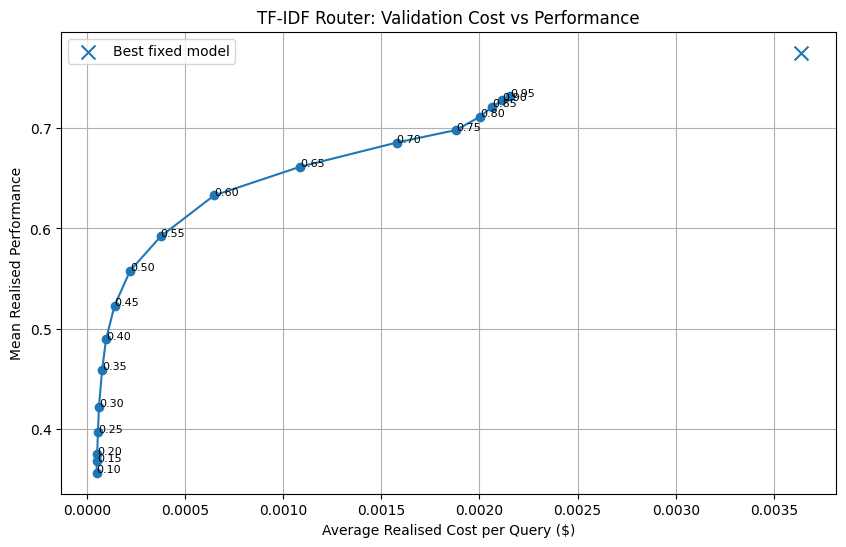

In [27]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))

plt.plot(
    threshold_results["mean_cost"],
    threshold_results["mean_performance"],
    marker="o"
)

for _, row in threshold_results.iterrows():

    plt.annotate(
        f'{row["threshold"]:.2f}',
        (
            row["mean_cost"],
            row["mean_performance"]
        ),
        fontsize=8
    )

plt.scatter(
    [best_fixed_val_cost],
    [best_fixed_val_performance],
    marker="x",
    s=100,
    label="Best fixed model"
)

plt.xlabel("Average Realised Cost per Query ($)")
plt.ylabel("Mean Realised Performance")
plt.title(
    "TF-IDF Router: Validation Cost vs Performance"
)

plt.legend()
plt.grid(True)

plt.show()

In [28]:
oracle_val_scores = []
oracle_val_costs = []

for i in range(len(Y_val_np)):

    scores = Y_val_np[i]
    costs = C_val_np[i]

    best_score = scores.max()

    candidates = np.where(
        scores == best_score
    )[0]

    selected = candidates[
        np.argmin(
            costs[candidates]
        )
    ]

    oracle_val_scores.append(
        scores[selected]
    )

    oracle_val_costs.append(
        costs[selected]
    )

oracle_val_performance = np.mean(
    oracle_val_scores
)

oracle_val_cost = np.mean(
    oracle_val_costs
)

print(
    "Oracle validation performance:",
    oracle_val_performance
)

print(
    "Oracle validation cost:",
    oracle_val_cost
)

Oracle validation performance: 0.8941638
Oracle validation cost: 0.00027800963


In [29]:
cheapest_val_model = (
    val_fixed_summary["mean_cost"].idxmin()
)

print(
    "Cheapest fixed model:",
    cheapest_val_model
)

print(
    "Performance:",
    val_fixed_summary.loc[
        cheapest_val_model,
        "mean_performance"
    ]
)

print(
    "Cost:",
    val_fixed_summary.loc[
        cheapest_val_model,
        "mean_cost"
    ]
)

Cheapest fixed model: mistralai/mistral-7b-chat
Performance: 0.31587544
Cost: 4.7787453e-05


In [30]:
comparison = pd.DataFrame([
    {
        "system": "Cheapest Fixed",
        "performance": val_fixed_summary.loc[
            cheapest_val_model,
            "mean_performance"
        ],
        "cost": val_fixed_summary.loc[
            cheapest_val_model,
            "mean_cost"
        ]
    },

    {
        "system": "Best Fixed",
        "performance": best_fixed_val_performance,
        "cost": best_fixed_val_cost
    },

    {
        "system": "TF-IDF Router",
        "performance": float(
            best_operating_point[
                "mean_performance"
            ]
        ),
        "cost": float(
            best_operating_point[
                "mean_cost"
            ]
        )
    },

    {
        "system": "Oracle",
        "performance": oracle_val_performance,
        "cost": oracle_val_cost
    }
])

display(comparison)

,system,performance,cost
0,Cheapest Fixed,0.315875,0.000048
1,Best Fixed,0.775044,0.003638
2,TF-IDF Router,0.731816,0.002157
3,Oracle,0.894164,0.000278


In [31]:
router_cost = float(
    best_operating_point["mean_cost"]
)

cost_saving_vs_best = (
    1
    - router_cost / best_fixed_val_cost
) * 100

print(
    "Cost saving vs best fixed model:",
    round(
        cost_saving_vs_best,
        2
    ),
    "%"
)

Cost saving vs best fixed model: 40.7 %


In [32]:
import joblib

joblib.dump(
    vectorizer,
    "/content/drive/MyDrive/router_tfidf_vectorizer.joblib"
)

joblib.dump(
    ridge,
    "/content/drive/MyDrive/router_ridge_baseline.joblib"
)

np.save(
    "/content/drive/MyDrive/router_mean_train_cost.npy",
    mean_train_cost
)

np.save(
    "/content/drive/MyDrive/router_selected_tfidf_threshold.npy",
    np.array([SELECTED_THRESHOLD])
)

threshold_results.to_csv(
    "/content/drive/MyDrive/tfidf_threshold_results.csv",
    index=False
)

print("Baseline artifacts saved.")

Baseline artifacts saved.
